# Netflix Movie Recommendation System

## Capstone Project

### Objective
Build a content-based movie recommendation system and analyze movie genres using exploratory data analysis (EDA).

### Workflow
1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Genre Analysis
6. Recommendation System (TF-IDF + Cosine Similarity)
7. Results
8. Conclusion
9. Future Scope


In [ ]:
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -q ml-latest-small.zip

--2026-07-01 05:37:24--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  --.-KB/s    in 0.1s    

2026-07-01 05:37:24 (6.23 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]



In [ ]:
import pandas as pd

movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

movies.head()

Movies: (9742, 3)
Ratings: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


# Explore the dataset:


In [ ]:
# First 5 rows
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# First 5 ratings
ratings.head()


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
# Information about datasets
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
# Merge ratings and movies datasets
data = pd.merge(ratings, movies, on='movieId')

print("Merged Dataset Shape:", data.shape)

data.head()

Merged Dataset Shape: (100836, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [ ]:
data.isnull().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0


In [ ]:
top_movies = data.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

print(top_movies)

title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64


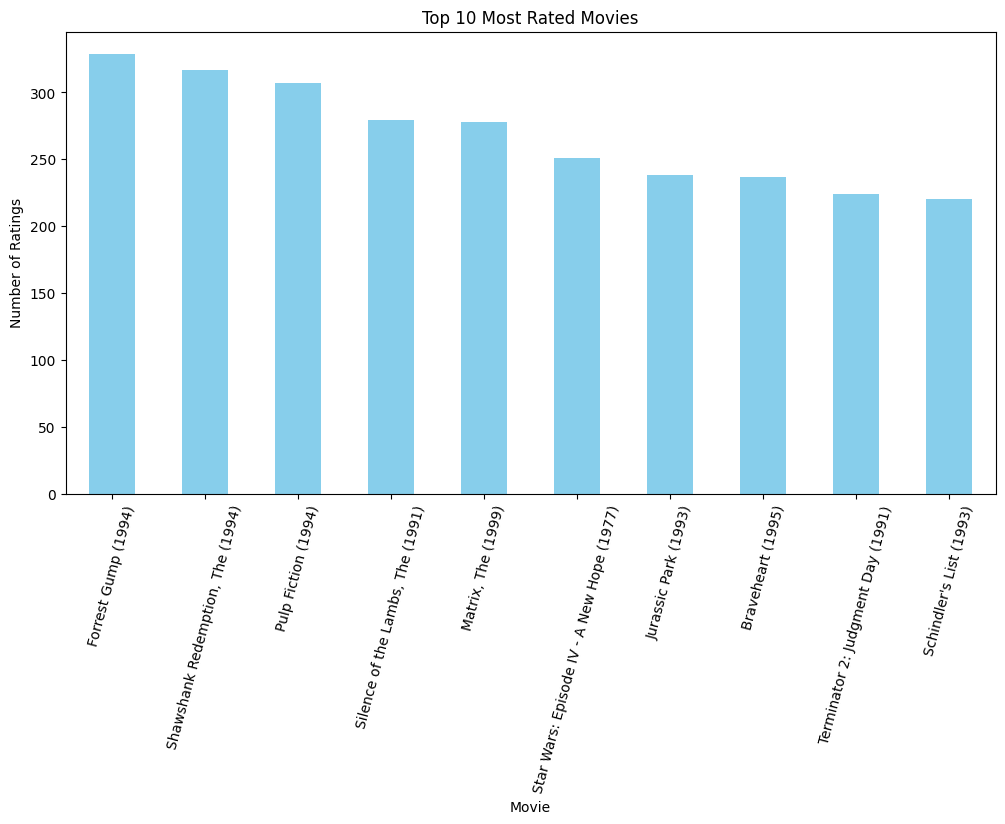

In [ ]:
import matplotlib.pyplot as plt

top_movies.plot(kind="bar", figsize=(12,6), color="skyblue")

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=75)

plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')

movies['genres'] = movies['genres'].fillna('')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print(tfidf_matrix.shape)

(9742, 23)


In [ ]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(cosine_sim.shape)

(9742, 9742)


In [ ]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [ ]:
def recommend_movies(title, cosine_sim=cosine_sim):
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]

In [ ]:
recommend_movies("Toy Story (1995)")

,title
1706,Antz (1998)
2355,Toy Story 2 (1999)
2809,"Adventures of Rocky and Bullwinkle, The (2000)"
3000,"Emperor's New Groove, The (2000)"
3568,"Monsters, Inc. (2001)"
6194,"Wild, The (2006)"
6486,Shrek the Third (2007)
6948,"Tale of Despereaux, The (2008)"
7760,Asterix and the Vikings (Astérix et les Viking...
8219,Turbo (2013)


In [ ]:
recommend_movies("Jumanji (1995)")

,title
53,"Indian in the Cupboard, The (1995)"
109,"NeverEnding Story III, The (1994)"
767,Escape to Witch Mountain (1975)
1514,Darby O'Gill and the Little People (1959)
1556,Return to Oz (1985)
1617,"NeverEnding Story, The (1984)"
1618,"NeverEnding Story II: The Next Chapter, The (1..."
1799,Santa Claus: The Movie (1985)
3574,Harry Potter and the Sorcerer's Stone (a.k.a. ...
6075,"Chronicles of Narnia: The Lion, the Witch and ..."


In [ ]:
recommend_movies("Batman Begins (2005)")

,title
6710,"Dark Knight, The (2008)"
8387,Need for Speed (2014)
6852,Eagle Eye (2008)
8103,"Good Day to Die Hard, A (2013)"
8166,"Fast & Furious 6 (Fast and the Furious 6, The)..."
7768,"Dark Knight Rises, The (2012)"
7599,"Fast Five (Fast and the Furious 5, The) (2011)"
8233,Man of Tai Chi (2013)
8149,"Grandmaster, The (Yi dai zong shi) (2013)"
7031,Night at the Museum: Battle of the Smithsonian...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')

movies['genres'] = movies['genres'].fillna('')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print(tfidf_matrix.shape)

(9742, 23)


In [ ]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

print(cosine_sim.shape)

(9742, 9742)


In [ ]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [ ]:
def recommend_movies(title):
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    return movies[['title', 'genres']].iloc[movie_indices]

In [ ]:
recommend_movies("Toy Story (1995)")

,title,genres
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


In [ ]:
movie_name = input("Enter a movie name: ")

try:
    recommendations = recommend_movies(movie_name)
    print("\nRecommended Movies:\n")
    print(recommendations)
except KeyError:
    print("Movie not found. Please enter the exact movie name.")

Enter a movie name: Heat (1995)

Recommended Movies:

                                  title                 genres
22                     Assassins (1995)  Action|Crime|Thriller
138   Die Hard: With a Vengeance (1995)  Action|Crime|Thriller
156                     Net, The (1995)  Action|Crime|Thriller
249         Natural Born Killers (1994)  Action|Crime|Thriller
417               Judgment Night (1993)  Action|Crime|Thriller
509                       Batman (1989)  Action|Crime|Thriller
793                     Die Hard (1988)  Action|Crime|Thriller
1306                   Hard Rain (1998)  Action|Crime|Thriller
1315    Replacement Killers, The (1998)  Action|Crime|Thriller
1325               U.S. Marshals (1998)  Action|Crime|Thriller


Conclusion

This project builds a Netflix-style movie recommendation system using Machine Learning. It uses Content-Based Filtering with TF-IDF Vectorization and Cosine Similarity to recommend similar movies based on their genres.

Technologies Used:
• Python
• Pandas
• Scikit-learn
• Matplotlib
• Google Colab

Result:
The system successfully recommends movies similar to the user's selected movie.

# Additional Analysis (Added)

## Objective 1: Most Popular Genres
The following cells calculate the most common genres.

## Objective 3: Best and Worst Rated Genres
The following cells calculate the average rating for each genre.

## Conclusion
This completes all objectives mentioned in the capstone project.


In [ ]:
# Most Popular Genres
genre_counts = (
    data['genres']
    .dropna()
    .str.split('|')
    .explode()
    .value_counts()
)

print("Most Popular Genres:")
print(genre_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar')
plt.title("Most Popular Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Best and Worst Rated Genres

genre_rating = (
    data[['genres','rating']]
    .dropna()
    .assign(genres=lambda df: df['genres'].str.split('|'))
    .explode('genres')
    .groupby('genres')['rating']
    .mean()
    .sort_values(ascending=False)
)

print("Top Rated Genres")
print(genre_rating.head())

print("\nLowest Rated Genres")
print(genre_rating.tail())

plt.figure(figsize=(10,5))
genre_rating.sort_values().plot(kind='barh')
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.tight_layout()
plt.show()


In [ ]:
print('Project Objectives Completed:')
print('✓ Popular Genres')
print('✓ Recommendation System')
print('✓ Best and Worst Rated Genres')
print('\nConclusion:')
print('A content-based recommendation engine was successfully developed using TF-IDF and Cosine Similarity. Genre popularity and average genre ratings were also analysed.')

# Final Conclusion

### Results
- Built a Content-Based Recommendation Engine using **TF-IDF** and **Cosine Similarity**.
- Identified the most popular movie genres.
- Identified the highest-rated and lowest-rated genres.
- Generated movie recommendations based on content similarity.

### Future Scope
- Hybrid recommendation system
- Collaborative filtering
- Deep learning recommendation models
- Deployment using Streamlit or Flask



# Exploratory Data Analysis (EDA)

The following visualizations help understand the dataset before building the recommendation engine.


In [ ]:

import matplotlib.pyplot as plt

# Rating Distribution
plt.figure(figsize=(7,4))
data['rating'].hist(bins=10)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [ ]:

# Top 10 Most Rated Movies
top_movies = data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_movies.plot(kind='bar')
plt.title('Top 10 Most Rated Movies')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



## Key Insights

- The rating distribution helps identify user preferences.
- Popular movies usually receive more ratings.
- Genre analysis reveals audience interests.
- Content-based filtering recommends movies with similar metadata instead of relying on user history.



# Project Highlights

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- TF-IDF Vectorizer
- Cosine Similarity

### Skills Demonstrated
- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Recommendation Systems
- Data Visualization
